# Network Intrusion Detection using Random Forest

## Project Overview

This project builds a binary network intrusion detection model that classifies network connections as **Normal** or **Attack**.

The workflow covers data loading, feature preparation, categorical encoding, a baseline Random Forest model, randomized hyperparameter tuning with cross-validation, test-set evaluation, and error analysis.

> **Note:** The dataset files are not included in this repository. Place `KDDTrain+.txt` and `KDDTest+.txt` inside the `data/` folder before running the notebook.


## 1. Data Loading and Preparation

The dataset contains network connection features. The target is converted into a binary label:

- `0` → Normal
- `1` → Attack

The original `attack` and `difficulty` columns are removed from the feature matrix.


In [2]:
import pandas as pd

columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'attack',
    'difficulty'
]

train_df = pd.read_csv(
    "data/KDDTrain+.txt",
    names=columns
)

test_df = pd.read_csv(
    "data/KDDTest+.txt",
    names=columns
)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (125973, 43)
Testing shape: (22544, 43)


In [3]:
train_df['label'] = train_df['attack'].apply(
    lambda x: 0 if x == 'normal' else 1
)
test_df['label'] = test_df['attack'].apply(
    lambda x: 0 if x == 'normal' else 1
)
print("Training class distribution:")
print(train_df['label'].value_counts())
print("\nTraining class percentage:")
print(train_df['label'].value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(test_df['label'].value_counts())
print("\nTesting class percentage:")
print(test_df['label'].value_counts(normalize=True)* 100)

Training class distribution:
label
0    67343
1    58630
Name: count, dtype: int64

Training class percentage:
label
0    53.458281
1    46.541719
Name: proportion, dtype: float64

Testing class distribution:
label
1    12833
0     9711
Name: count, dtype: int64

Testing class percentage:
label
1    56.924237
0    43.075763
Name: proportion, dtype: float64


In [4]:
X_train = train_df.drop(
    columns=['attack','difficulty','label']
)

y_train = train_df['label']

X_test = test_df.drop(
    columns=['attack','difficulty','label']
)

y_test = test_df['label']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (125973, 41)
y_train shape: (125973,)
X_test shape: (22544, 41)
y_test shape: (22544,)


In [5]:
categorical_features = [
    'protocol_type',
    'service',
    'flag'
]
numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Categorical features: ['protocol_type', 'service', 'flag']

Number of numerical features: 38
Number of categorical features: 3


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'protocol_type',
    'service',
    'flag'
]
numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)
print("Preprocessor created successfully.")

Preprocessor created successfully.


In [8]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (125973, 122)
Encoded testing shape: (22544, 122)


## 2. Baseline Random Forest

A Random Forest classifier with 100 trees is trained on the encoded training data. The baseline provides a reference point before hyperparameter tuning.


In [9]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)
print("Random Forest model created.")

Random Forest model created.


In [11]:
rf_model.fit(
    X_train_encoded,
    y_train
)
print("Random Forest training completed.")

Random Forest training completed.


In [12]:
y_pred = rf_model.predict(X_test_encoded)

print("Predictions completed")
print("Number of predictions:", len(y_pred))

Predictions completed
Number of predictions: 22544


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Results")
print("--------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Random Forest Results
--------------------
Accuracy : 0.7784
Precision : 0.9690
Recall: 0.6309
F1 Score : 0.7642


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal','Attack']
))

              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



In [15]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[9452  259]
 [4737 8096]]


## 3. Hyperparameter Tuning

RandomizedSearchCV is used with 3-fold cross-validation and F1 score as the optimization metric.

The search evaluates 10 sampled parameter combinations from the following space:

- Number of trees: 100, 150, 200
- Maximum depth: None, 20, 30
- Minimum samples split: 2, 5, 10
- Minimum samples leaf: 1, 2, 4
- Maximum features: `sqrt`, `log2`


In [25]:
from sklearn.pipeline import Pipeline  
from sklearn.ensemble import RandomForestClassifier

rf_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])
print("Tuning pipeline created.")

Tuning pipeline created.


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [None, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
}

print("Correct pipeline parameter grid ceeated.")

Correct pipeline parameter grid ceeated.


In [27]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)


print("RandomizedSearchCV created")

RandomizedSearchCV created


In [30]:
print("Starting hyperparameter search..")

random_search.fit(
    X_train,
    y_train
)
print("Hyperparameter search complete.")

Starting hyperparameter search..
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter search complete.


In [31]:
print("Best Hyperparameters:")
print(random_search.best_params_)

Best Hyperparameters:
{'classifier__n_estimators': 150, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}


In [32]:
print("Best Cross-Validation F1 Score:")
print(random_search.best_score_)

Best Cross-Validation F1 Score:
0.9987796384066923


In [34]:
best_model = random_search.best_estimator_
print("Best model selected.")

Best model selected.


In [35]:
y_pred_tuned = best_model.predict(X_test)
print("Test predictions generated.")

Test predictions generated.


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned Random Forest Results
---------------------------
Accuracy : 0.7769251242015613
Precision: 0.9687650168188371
Recall   : 0.628379957920985
F1 Score : 0.7623008933213593


In [38]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=['Normal', 'Attack']
    )
)

              precision    recall  f1-score   support

      Normal       0.66      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



In [39]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Confusion Matrix:")
print(cm_tuned)

Confusion Matrix:
[[9451  260]
 [4769 8064]]


In [40]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Baseline Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        0.7784,
        tuned_accuracy
    ],
    'Precision': [
        0.9700,
        tuned_precision
    ],
    'Recall': [
        0.6309,
        tuned_recall
    ],
    'F1 Score': [
        0.7600,
        tuned_f1
    ]
})

print(model_comparison)

                    Model  Accuracy  Precision   Recall  F1 Score
0  Baseline Random Forest  0.778400   0.970000  0.63090  0.760000
1     Tuned Random Forest  0.776925   0.968765  0.62838  0.762301


In [41]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Random Forest,0.7784,0.9700,0.6309,0.7600
1,Tuned Random Forest,0.7769,0.9688,0.6284,0.7623


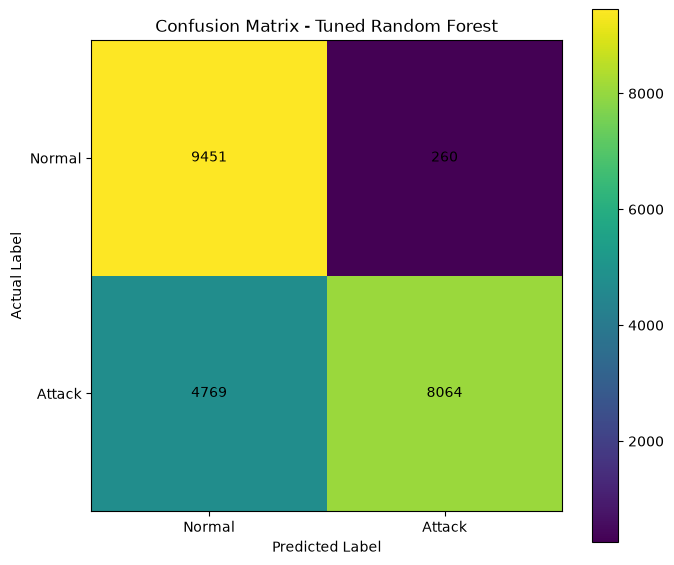

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))

plt.imshow(cm_tuned, interpolation='nearest')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.colorbar()

classes = ['Normal', 'Attack']
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Add the numbers inside each cell
for i in range(cm_tuned.shape[0]):
    for j in range(cm_tuned.shape[1]):
        plt.text(
            j,
            i,
            format(cm_tuned[i, j], 'd'),
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

## 4. Results and Discussion

Hyperparameter tuning produced a model with performance very close to the baseline. The tuned model's F1 score improved slightly, but accuracy, precision, and recall were marginally lower.

The main limitation is attack recall: a substantial number of actual attacks are classified as normal traffic. This is reflected in the false-negative count in the confusion matrix.

### Key Findings

- Baseline accuracy: **77.84%**
- Tuned accuracy: **77.69%**
- Baseline F1: **76.42%**
- Tuned F1: **76.23%**
- Tuned attack recall: **62.84%**
- Tuned false negatives: **4,769**

The results indicate that conventional hyperparameter tuning alone did not meaningfully improve the intrusion detection model. Future work could investigate class weighting, decision-threshold optimization, feature engineering, or alternative algorithms.
